In [1]:
## Create a vector of the required packages for this analysis
req_packages <- c("ggplot2", "ggpubr", "ggrepel", "janitor", "multcompView", 
                  "RColorBrewer", "tidyverse", "vegan", "viridis")
## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

## Load in EQTL results files

In [2]:
# load in EQTLs
cis <- read_csv("../workflow/eqtl/tensorqtl/results/vg_annotated.cis_qtl_pairs.txt.gz") %>%
    filter(pval_nominal < 0.05) %>%
    mutate(relationship = "cis")
trans <- read_tsv("../workflow/eqtl/tensorqtl/results/vg_annotated.trans_qtl_pairs.txt.gz") %>%
    mutate(relationship = "trans")

## reformat the data frames to combine them
trans <- trans %>%
    select(variant_id, phenotype_id, af, pval, relationship)
cis <- cis %>%
    rename(pval = pval_nominal) %>%
    select(variant_id, phenotype_id, af, pval, relationship)

## combine the two dataframes
eqtl <- rbind(trans, cis)

head(eqtl)

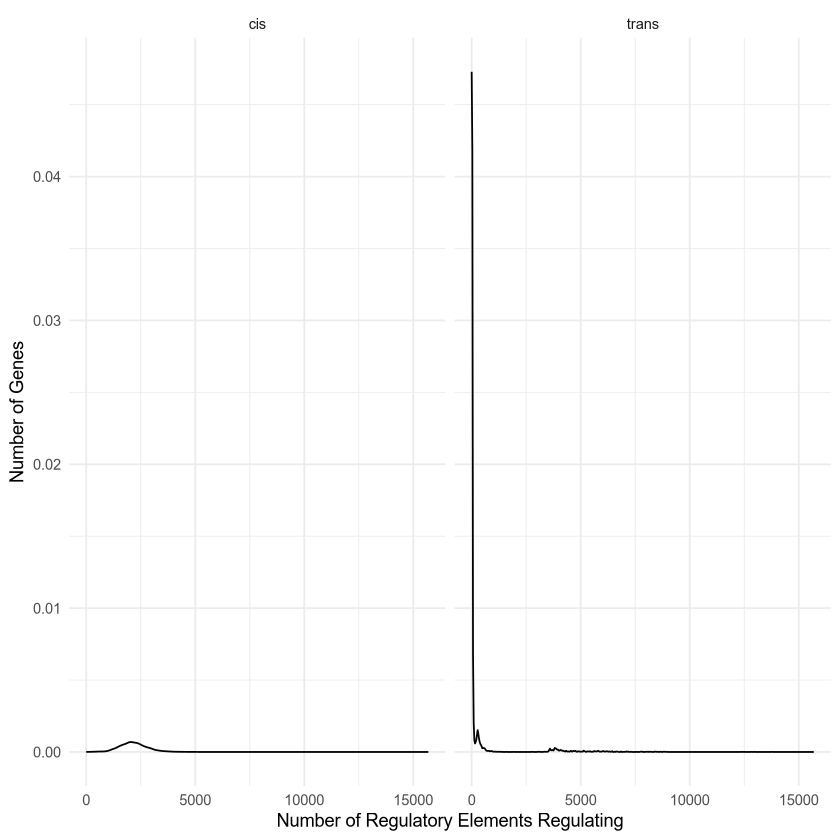

In [ ]:
## count the number of regulatory elements per gene
gene_reg_number <- eqtl %>%
    filter(pval < 0.05) %>%
    group_by(phenotype_id, relationship) %>%
    count() %>%
    ggplot(aes(x = n)) +
        geom_density() +
        labs(x = "Number of Regulatory Elements Regulating", y = "Number of Genes") +
        theme_minimal() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~relationship)
gene_reg_number

In [ ]:
## save plot
ggsave("figures/eqtl_fusion/tensorqtl_regpergene.png", gene_reg_number)

Saving 7 x 7 in image


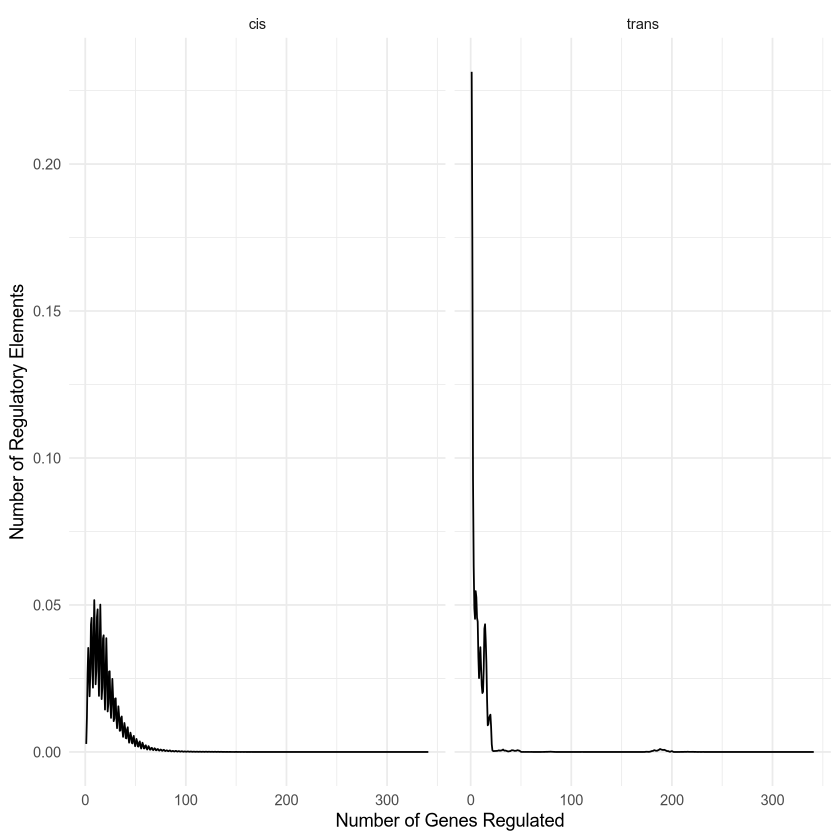

In [ ]:
## count the number of genes per regulatory element
reg_gene_number <- eqtl %>%
    filter(pval < 0.05) %>%
    group_by(variant_id, relationship) %>%
    count() %>%
    ggplot(aes(x = n)) +
        geom_density() +
        labs(x = "Number of Genes Regulated", y = "Number of Regulatory Elements") +
        theme_minimal() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~relationship)
reg_gene_number

In [ ]:
## save plot
ggsave("figures/eqtl_fusion/tensorqtl_geneperreg.png", reg_gene_number)

Saving 7 x 7 in image


### Add chromosome information for SNPs

In [ ]:
## load in SNP information
snps <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated_snps.vcf", skip = 513) %>%
    janitor::clean_names() %>%
    filter(grepl("Chr_", number_chrom))

## load in GTF
gtf_raw <- read_tsv("/home/yahmed-labshare/data/genomes/virilis_group/americana/SB.02.06/Muller/Polished/gffcompare/sb.02.06.combined.gtf", col_names = FALSE)

## clean up GTF for downstream use
colnames(gtf_raw) <- c("chromosome", "source", "feature", "start", "end", "score", "strand", "frame", "attribute")
gtf <- gtf_raw %>%
    filter(feature == "transcript" & grepl("Chr_", chromosome)) %>%
    mutate(attribute = str_remove_all(attribute, "\""),
           attribute = str_remove_all(attribute, " "),
           chromosome = str_remove_all(chromosome, "_RagTag")) %>%
    separate_wider_delim(attribute, delim = ";", names = c("transcript", "gene_id", "gene", "extra"), too_many = "drop") %>%
    mutate(transcript = str_remove_all(transcript, "transcript_id"),
           gene_id = str_remove_all(gene_id, "gene_id"),
           gene = str_remove_all(gene, "oId"),
           gene = str_remove_all(gene, "gene_name"),
           extra = str_remove_all(chromosome, "tss_id"))
head(gtf)
head(snps)

Rows: 3049807 Columns: 215
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (213): #CHROM, ID, REF, ALT, FILTER, INFO, FORMAT, AA_99_06, BB_05_10, B...
dbl   (2): POS, QUAL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 283442 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): X1, X2, X3, X6, X7, X8, X9
dbl (2): X4, X5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


chromosome,source,feature,start,end,score,strand,frame,transcript,gene_id,gene,extra
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,AUGUSTUS,transcript,4872,5240,.,+,.,gffcompare/sb.02.06/sb.02.06_00000001,XLOC_000001,g1.t1,Chr_2
Chr_2,AUGUSTUS,transcript,5363,5692,.,+,.,gffcompare/sb.02.06/sb.02.06_00000002,XLOC_000002,g2.t1,Chr_2
Chr_2,AUGUSTUS,transcript,7348,7590,.,+,.,gffcompare/sb.02.06/sb.02.06_00000003,XLOC_000003,g3.t1,Chr_2
Chr_2,AUGUSTUS,transcript,11257,12588,.,+,.,gffcompare/sb.02.06/sb.02.06_00000004,XLOC_000004,g4.t1,Chr_2
Chr_2,AUGUSTUS,transcript,12642,13982,.,+,.,gffcompare/sb.02.06/sb.02.06_00000005,XLOC_000005,g5.t1,Chr_2
Chr_2,AUGUSTUS,transcript,17648,20284,.,+,.,gffcompare/sb.02.06/sb.02.06_00000006,XLOC_000006,g6.t1,Chr_2


number_chrom,pos,id,ref,alt,qual,filter,info,format,aa_99_06,⋯,wr_06_18,wr_06_22,wr_06_24,wr_06_40,wr_06_44,ws_07_06,ws_07_10,ws_07_16,ws_07_18,ws_07_20
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,165178,>5480>5483,G,T,9.54243,lowad,"DP=0;AT=>5480>5482>5483,>5480>5481>5483;AF=0.264706",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:0:0,0:-6.32684,-6.32684,-6.32684:0:-2.19723:14.5681:0",⋯,"0/0:0:0,0:-5.49804,-5.49804,-5.49804:0:-2.19723:12.6597:0","1/1:0:0,0:-13.4507,-13.4507,-13.4507:0:-2.19723:30.9712:0","0/0:0:0,0:-7.67521,-7.67521,-7.67521:0:-2.19723:17.6728:0","0/0:0:0,0:-9.1202,-9.1202,-9.1202:0:-2.19723:21:0","0/0:0:0,0:-8.04015,-8.04015,-8.04015:0:-2.19723:18.5131:0","0/0:0:0,0:-17.3764,-17.3764,-17.3764:0:-2.19723:40.0105:0","1/1:0:0,0:-7.34892,-7.34892,-7.34892:0:-2.19723:16.9215:0","0/0:0:0,0:-6.04717,-6.04717,-6.04717:0:-2.19723:13.9241:0","0/0:0:0,0:-9.50107,-9.50107,-9.50107:0:-2.19723:21.877:0","0/0:0:0,0:-5.18199,-5.18199,-5.18199:0:-2.19723:11.9319:0"
Chr_2,169979,>5642>5645,C,T,31.10650,lowad;lowdepth,"DP=1;AT=>5642>5644>5645,>5642>5643>5645;AF=1",GT:DP:AD:GL:GQ:GP:XD:MAD,"1/1:0:0,0:-2.07034,-2.07034,-2.07034:0:-2.19723:4.76712:0",⋯,"1/1:0:0,0:-3.71233,-3.71233,-3.71233:0:-2.19723:8.54795:0","1/1:0:0,0:-4.86649,-4.86649,-4.86649:0:-2.19723:11.2055:0","1/1:0:0,0:-3.08171,-3.08171,-3.08171:0:-2.19723:7.09589:0","1/1:0:0,0:-1.51706,-1.51706,-1.51706:0:-2.19723:3.49315:0","1/1:0:0,0:-2.21312,-2.21312,-2.21312:0:-2.19723:5.09589:0","1/1:0:0,0:-7.77567,-7.77567,-7.77567:0:-2.19723:17.9041:0","1/1:0:0,0:-10.8752,-10.8752,-10.8752:0:-2.19723:25.0411:0","1/1:0:0,0:-11.1132,-11.1132,-11.1132:0:-2.19723:25.589:0","1/1:0:0,0:-3.22449,-3.22449,-3.22449:0:-2.19723:7.42466:0","1/1:0:0,0:-6.7405,-6.7405,-6.7405:0:-2.19723:15.5205:0"
Chr_2,171428,>5705>5708,A,G,40.12800,lowdepth;lowad,"DP=367;AT=>5705>5707>5708,>5705>5706>5708;AF=0.622549",GT:DP:AD:GL:GQ:GP:XD:MAD,"0/0:2:2,0:-7.33799,-7.63902,-11.6347:3:-1.50411:21.65:2",⋯,"0/0:3:3,0:-3.92001,-4.99475,-10.9882:10:-1.17945:15.9167:3","1/1:0:0,0:-7.36131,-7.36131,-7.36131:0:-2.19723:16.95:0","1/1:0:0,0:-6.61577,-6.61577,-6.61577:0:-2.19723:15.2333:0","1/1:0:0,0:-5.0523,-5.0523,-5.0523:0:-2.19723:11.6333:0","0/0:6:6,0:-3.10407,-4.4051,-16.3921:13:-1.1474:16.0167:6","1/1:0:0,0:-8.2878,-8.2878,-8.2878:0:-2.19723:19.0833:0","1/1:0:0,0:-6.48548,-6.48548,-6.48548:0:-2.19723:14.9333:0","0/0:4:4,0:-3.60903,-4.38719,-12.3785:7:-1.25276:14.95:4","1/1:0:0,0:-7.31788,-7.31788,-7.31788:0:-2.19723:16.85:0","1/1:0:0,0:-6.6592,-6.6592,-6.6592:0:-2.19723:15.3333:0"
Chr_2,172799,>5764>5767,C,T,9.54243,lowad,"DP=0;AT=>5764>5766>5767,>5764>5765>5767;AF=0.946078",GT:DP:AD:GL:GQ:GP:XD:MAD,"1/1:0:0,0:-5.27921,-5.27921,-5.27921:0:-2.19723:12.1558:0",⋯,"1/1:0:0,0:-5.83285,-5.83285,-5.83285:0:-2.19723:13.4306:0","1/1:0:0,0:-5.97187,-5.97187,-5.97187:0:-2.19723:13.7507:0","1/1:0:0,0:-5.71597,-5.71597,-5.71597:0:-2.19723:13.1615:0","0/0:0:0,0:-4.00216,-4.00216,-4.00216:0:-2.19723:9.2153:0","0/0:0:0,0:-4.57302,-4.57302,-4.57302:0:-2.19723:10.5297:0","1/1:0:0,0:-5.34442,-5.34442,-5.34442:0:-2.19723:12.3059:0","1/1:0:0,0:-5.17956,-5.17956,-5.17956:0:-2.19723:11.9263:0","1/1:0:0,0:-4.54842,-4.54842,-4.54842:0:-2.19723:10.4731:0","1/1:0:0,0:-5.53511,-5.53511,-5.53511:0:-2.19723:12.745:0","1/1:0:0,0:-3.94434,-3.94434,-3.94434:0:-2.19723:9.08215:0"
Chr_2,172880,>5769>5772,T,G,9.54243,lowad,"DP=0;AT=>5769>5771>5772,>5769>5770>5772;AF=0.568627",GT:DP:AD:GL:GQ:GP:XD:MAD,"1/1:0:0,0:-13.4632,-13.4632,-13.4632:0:-2.19723:31:0",⋯,"1/1:0:0,0:-12.9109,-12.9109,-12.9109:0:-2.19723:29.7284:0","0/0:0:0,0:-17.1359,-17.1359,-17.1359:0:-2.19723:39.4568:0","1/1:0:0,0:-10.5839,-10.5839,-10.5839:0:-2.19723:24.3704:0","0/0:0:0,0:-7.8334,-7.8334,-7.8334:0:-2.19723:18.037:0","0/0:0:0,0:-6.43937,-6.43937,-6.43937:0:-2.19723:14.8272:0","1/1:0:0,0:-6.99698,-6.99698,-6.99698:0:-2.19723:16.1111:0","0/0:0:0,0:-10.911,-10.911,-10.911:0:-2.19723:25.1235:0","1/1:0:0,0:-7.78515

In [ ]:
## add EQTL location information
eqtl_loc <- snps %>%
    select(number_chrom, pos, id) %>%
    unique() %>%
    rename(variant_id = id) %>%
    right_join(eqtl, by = "variant_id")
eqtl_loc <- gtf %>%
    select(gene, chromosome, start) %>%
    rename(phenotype_id = gene, phenotype_start = start) %>%
    right_join(eqtl_loc, by = "phenotype_id", relationship = "many-to-many")

head(eqtl_loc)

Warning message in right_join(., eqtl, by = "variant_id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 2945299 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


phenotype_id,chromosome,phenotype_start,number_chrom,pos,variant_id,af,pval,relationship
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
ATPsynD,Chr_2,113108,Chr_2,172880,>5769>5772,0.5714285,0.005984385,cis
ATPsynD,Chr_2,113108,Chr_2,172880,>5769>5772,0.5714285,0.005984385,cis
ATPsynD,Chr_2,113108,Chr_2,172880,>5769>5772,0.5714285,0.005984385,cis
ATPsynD,Chr_2,113108,Chr_2,179596,>6080>6083,0.1785714,0.037240392,cis
ATPsynD,Chr_2,113108,Chr_2,179596,>6080>6083,0.1785714,0.037240392,cis
ATPsynD,Chr_2,113108,Chr_2,179596,>6080>6083,0.1785714,0.037240392,cis


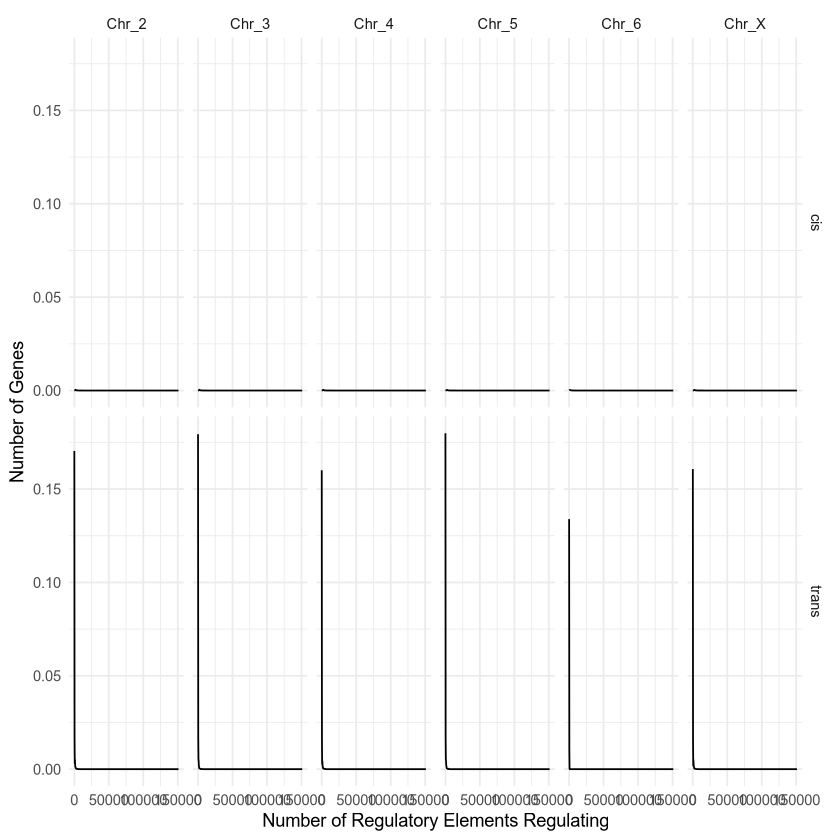

In [ ]:
## count the number of regulatory elements per gene
gene_reg_number <- eqtl_loc %>%
    filter(pval < 0.05 & grepl("Chr_", number_chrom)) %>%
    group_by(phenotype_id, number_chrom, relationship) %>%
    count() %>%
    ggplot(aes(x = n)) +
        geom_density() +
        labs(x = "Number of Regulatory Elements Regulating", y = "Number of Genes") +
        theme_minimal() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_grid(cols = vars(number_chrom), rows = vars(relationship))
gene_reg_number

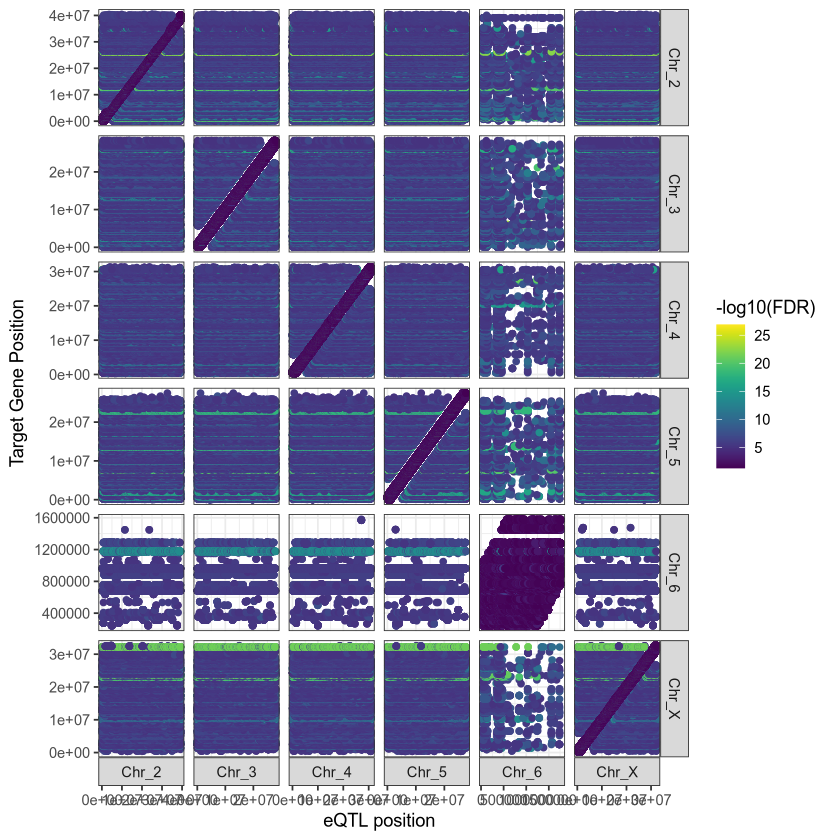

In [ ]:
## plot the relative location of each eQTL and the effected gene
eqtl_loc_graph <- eqtl_loc %>%
    na.omit() %>%
    ggplot(aes(x = pos, y = phenotype_start, color = -log10(pval)), size = 0.001) +
        geom_point() +
        labs(x = "eQTL position", y = "Target Gene Position", color = "-log10(FDR)") +
        scale_color_viridis() +
        # scale_x_continuous(expand = c(0, 0)) +
        # scale_y_continuous(expand = c(0, 0), limits = c(0, NA)) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_grid(cols = vars(number_chrom), rows = vars(chromosome),
                   scales = "free", switch = "x")
eqtl_loc_graph

In [ ]:
## save plot
ggsave("figures/eqtl_fusion/tensorqtl_eqtl_location.png", eqtl_loc_graph)

Saving 7 x 7 in image


## Investigate the role of population genetics in eQTL placement

In [ ]:
## load in population statistic information
f_stat <- read_tsv("../workflow/dna/results/vcftools/vg_annotated_vcftools.het") %>%
    janitor::clean_names()
hwe <- read_tsv("../workflow/dna/results/vcftools/vg_annotated_vcftools.hwe") %>%
    janitor::clean_names() %>%
    filter(grepl("Chr_", chr))
pi_site <- read_tsv("../workflow/dna/results/vcftools/vg_annotated_vcftools.sites.pi") %>%
    janitor::clean_names() %>%
    filter(grepl("Chr_", chrom))
fst <- read_tsv("../workflow/dna/results/vcftools/vg_annotated_vcftools.weir.fst") %>%
    janitor::clean_names() %>%
    filter(grepl("Chr_", chrom))
colnames(fst)[3] <- "fst"

## combine all of the statistics for each snp
snp_stat <- hwe %>%
    rename(hwe = p_hwe) %>%
    select(chr, pos, hwe, p_het_deficit, p_het_excess) %>%
    rename(chrom = chr) %>%
    full_join(pi_site, by = c("chrom", "pos")) %>%
    full_join(fst, by = c("chrom", "pos")) %>%
    na.omit() %>%
    mutate(across(any_of(c("hwe", "p_het_deficit", "p_het_excess", "pi", "fst")), ~p.adjust(., method = "BH")))
head(snp_stat)

Rows: 205 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): INDV
dbl (4): O(HOM), E(HOM), N_SITES, F

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 2903584 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): CHR, OBS(HOM1/HET/HOM2), E(HOM1/HET/HOM2)
dbl (5): POS, ChiSq_HWE, P_HWE, P_HET_DEFICIT, P_HET_EXCESS

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3049807 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): CHROM
dbl (2): POS, PI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to 

chrom,pos,hwe,p_het_deficit,p_het_excess,pi,fst
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Chr_2,165178,2.950416e-51,2.950461e-51,1.00000000,0.5012445,-0.07124287
Chr_2,171428,1.885077e-58,1.885087e-58,1.00000000,0.5012445,0.11218415
Chr_2,172799,5.112793e-19,5.116398e-19,1.00000000,0.3857379,0.16373668
Chr_2,172880,4.851554e-60,4.851554e-60,1.00000000,0.5012445,0.02732662
Chr_2,174809,2.181477e-60,2.181477e-60,1.00000000,0.5012445,0.02834825
Chr_2,175607,9.087130e-06,1.000000e+00,0.00186664,0.5012445,0.01745072


In [ ]:
## apply population genetic information to eQTL information
eqtl_stat <- snp_stat %>%
    rename(number_chrom = chrom) %>%
    pivot_longer(!c(number_chrom, pos), names_to = "stat", values_to = "number") %>%
    full_join(eqtl_loc, by = c("number_chrom", "pos"), relationship = "many-to-many") %>%
    filter(grepl("Chr_", number_chrom))
head(eqtl_stat)

number_chrom,pos,stat,number,variant_id,phenotype_id,af,pval,relationship
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
Chr_2,165178,hwe,2.950416e-51,>5480>5483,sav,0.5,0.01334340,cis
Chr_2,165178,hwe,2.950416e-51,>5480>5483,LOC6635223,0.5,0.04383355,cis
Chr_2,165178,hwe,2.950416e-51,>5480>5483,sav,0.5,0.01334340,cis
Chr_2,165178,hwe,2.950416e-51,>5480>5483,LOC6635223,0.5,0.04383355,cis
Chr_2,165178,hwe,2.950416e-51,>5480>5483,sav,0.5,0.01334340,cis
Chr_2,165178,hwe,2.950416e-51,>5480>5483,LOC6635223,0.5,0.04383355,cis


In [ ]:
# ## plot population genetic positions and visualize with eQTL colocalization
# eqtl_popgen_pos <- eqtl_stat %>%  
#     mutate(relationship = case_when(relationship == "cis" ~ "Cis Regulatory",
#                                     relationship == "trans" ~ "Trans Regulatory",
#                                     TRUE ~ "Non Regulatory"),
#            number_chrom = str_replace(number_chrom, "Chr_", "Chromosome ")) %>%
#     # mutate(order = case_when(regulatory == "Not Regulatory" ~ 1,
#     #                          regulatory == "Trans Regulatory Element" ~ 3,
#     #                          regulatory == "Cis Regulatory Element" ~ 2)) %>%
#     # arrange(order) %>%
#     filter(!is.na(stat)) %>%
#     ggplot(aes(x = pos, y = number, color = relationship), alpha = 0.25) +
#         geom_point() +
#         labs(color = "Regulatory Element?") +
#         scale_color_manual(values = c("green", "gray", "blue")) +
#         theme_minimal() +
#         theme(panel.background = element_rect(fill = "white", color = NA),
#               plot.background = element_rect(fill = "white", color = NA),
#               axis.title.x = element_blank(),
#               axis.text.x = element_blank(),
#               axis.title.y = element_blank(),
#               legend.position = "bottom") +
#         scale_x_continuous(expand = c(0, 0)) +
#         scale_y_continuous(expand = c(0, 0), limits = c(0,NA)) +
#         facet_grid(cols = vars(number_chrom), rows = vars(stat), 
#                    scales = "free", switch = "x", space = "free_x")
# eqtl_popgen_pos

In [ ]:
# ## save plot
# ggsave("figures/eqtl_fusion/tensorqtl_eqtl_popgen.png", eqtl_popgen_pos)